# Debruitage du pouls choroidien : passe-bande FIR vs Hankel/SSA

Quatre facons d'aller des **100 vecteurs singuliers temporels** au **pouls
cardiaque et a sa phase**. Toutes partent de la meme matrice `X` et de la meme
SVD rang 100 ; elles ne different que par *ou* et *comment* on debruite.

| | debruitage | combinaison | ordre |
|---|---|---|---|
| **0** | **aucun** -- Hilbert direct | `OptimizedSpectralCombination` | temoin |
| **1** | passe-bande FIR (chaine actuelle) | `OptimizedSpectralCombination` | combiner **puis** filtrer |
| **2** | Hankel + SVD (SSA) sur le pouls | `OptimizedSpectralCombination` | combiner **puis** debruiter |
| **3a** | Hankel + SVD **multicanal** (M-SSA) | la SSA elle-meme | debruiter **et** combiner d'un coup |
| **3b** | Hankel + SVD canal par canal | `OptimizedSpectralCombination` | debruiter **puis** combiner |

L'approche **0** est le temoin : on prend la combinaison optimisee et on lui
applique Hilbert **sans rien filtrer**. Elle repond a la question prealable
"a-t-on seulement besoin de debruiter ?" -- et rappelle que la phase analytique
n'a de sens que pour un signal a **bande etroite** (conditions de Bedrosian et
Nuttall). Sur un signal large bande, la frequence instantanee
$\dot\varphi/2\pi$ peut devenir **negative**, ce qui n'a aucune interpretation
physiologique. La section 7.4 mesure a quelle frequence ca arrive.

L'approche **1** est la chaine du package telle quelle. Les trois autres
remplacent -- ou deplacent -- le passe-bande par une **analyse en spectre
singulier** : on plonge le signal 1-D dans sa matrice trajectoire de Hankel, on
la decompose en valeurs singulieres, et on ne garde que la paire de composantes
qui oscille a la frequence cardiaque. Contrairement a un FIR, la SSA n'impose
aucune bande a l'avance : elle apprend la forme d'onde sur les donnees, ce qui
lui permet de garder une harmonique utile ou de suivre une derive de frequence
qu'un filtre a bande fixe couperait.

**3a vs 3b** repondent a la meme question par deux chemins : en 3a la SSA
multicanal fait office de combinateur (aucun appel a
`OptimizedSpectralCombination`), en 3b chaque canal est debruite separement puis
la combinaison optimisee du package reprend la main. Comparer 2, 3a et 3b, c'est
donc comparer **debruiter apres**, **debruiter en combinant**, et **debruiter
avant**.

## Ce qui est fixe pour tout le monde

- Condition `02_210721001 / 210721001before_rigidity / 210721001before_rigidity_OD`,
  ROI = **3/4 centraux x moitie superieure** du masque choroidien, un pixel =
  une trace, normalisation par frame, moyenne temporelle retiree.
- **SVD rang 100** sur cette matrice.
- **Canaux cardiaques** = exactement les candidates de
  `OptimizedSpectralCombination` (pic Lomb-Scargle a moins de `accept_tol_bpm`
  de la HR *et* concentration >= `min_concentration`). Les approches 2, 3a et 3b
  partent donc du meme jeu de vecteurs : l'ecart mesure la strategie de
  debruitage, rien d'autre.
- **Phase** : signal analytique de Hilbert, frequence instantanee
  $\dot\varphi/2\pi$ filtree par mediane sur un cycle.

## Un prealable a ne pas oublier

Le pipeline actuel travaille sur les **horodatages reels**, non uniformes :
Lomb-Scargle le tolere, et le FIR n'intervient qu'apres interpolation. **La SSA,
elle, exige un pas de temps constant** -- la matrice de Hankel suppose que
`x[i+j]` est a l'instant `t0 + (i+j) dt`. Les approches 2, 3a et 3b sont donc
calculees sur la grille uniforme de l'aligner, apres interpolation. Sur cette
condition il y a un trou de 1,35 s : c'est un cout reel des methodes SSA, chiffre
en section 2.

## 0. Environnement, chemins, chargement

In [1]:
from pathlib import Path
import csv
import re
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.signal import hilbert, medfilt

from ocularrigidity.motion.filters._1d import spatio_temporal_filter
from ocularrigidity.motion.projection._1d import project_into_separable_components
from ocularrigidity.motion.pulsation import (
    CardiacBand,
    PixelTraceConfig,
    PixelTraceSource,
)
from ocularrigidity.motion.pulsation.phase import (
    OptimizedSpectralCombination,
    SpectralCombinationConfig,
)
from ocularrigidity.motion.pulsation.rate import (
    LombScargleConfig,
    LombScargleRateEstimator,
    lomb_scargle_power,
)
from ocularrigidity.motion.pulsation.traces import Traces
from ocularrigidity.motion.video_timeline_aligner import VideoTimelineAligner
from ocularrigidity.scripts.one_cycle.astronauts import _prepared_registrator
from ocularrigidity.scripts.registration.astronauts import load_ordered_oct_series

# --- Condition ---------------------------------------------------------------
PATH_GENERAL = Path("E:/SANSORI")
SEGVAR_ROOT = Path("E:/NASA_Rigidity/SegmentationVariations")
MASK_VARIANT = "model1_scale_1.0"

SUBJECT = "210721001"
MOMENT_KEY = "before"
EYE = "OD"
REPLICAT = 1

# --- Entree (identique au notebook compare_pipeline_pydmd_bopdmd) ------------
COL_FRAC = (0.125, 0.875)     # 3/4 centraux des A-scans
ROW_FRAC = (0.0, 0.5)         # moitie superieure (interne) de l'epaisseur locale
BLOCK_SIZES = (1,)
RANK_SVD = 100

DIAG_BPM_RANGE = (20.0, 240.0)
BAND_FRAC = 0.2

# --- SSA ---------------------------------------------------------------------
# Longueur de fenetre de plongement, en CYCLES cardiaques. La regle usuelle
# (L ~ N/2) maximise la resolution spectrale ; ici on prefere un L cale sur la
# physiologie : assez long pour separer le fondamental de la derive, assez court
# pour laisser K = N - L + 1 colonnes et donc du moyennage anti-diagonal.
SSA_CYCLES = 3.0
SSA_N_COMP = 20               # composantes SSA examinees pour le regroupement
SSA_CYCLES_SWEEP = (1.0, 2.0, 3.0, 5.0, 8.0)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", DEVICE)

C:\Users\transformer\anaconda3\envs\pyOR\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


W0812 21:00:29.094000 264268 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


device = cuda


In [2]:
def resolve_condition(subject, moment_key, eye, replicat=1, root=PATH_GENERAL):
    """(ASTRO, MOMENT, CONDITION) a partir de l'ID sujet."""
    astros = [p for p in sorted(root.iterdir())
              if p.is_dir() and re.fullmatch(rf"\d{{2}}_{subject}", p.name)]
    if not astros:
        raise ValueError(f"sujet {subject} absent de {root}")
    astro = astros[0]
    key = {"before": "before", "after": "post", "post": "post"}[str(moment_key).lower()]
    moment_dir = astro / f"{subject}{key}_rigidity"
    if not moment_dir.is_dir():
        raise ValueError(f"{moment_dir.name} absent")

    def _rep(p):
        s = re.search(r"(\d*)$", p.name).group(1)
        return int(s) if s else 0

    conds = sorted((p for p in moment_dir.iterdir()
                    if p.is_dir() and re.search(rf"_{eye}\d*$", p.name)), key=_rep)
    if not 1 <= replicat <= len(conds):
        raise ValueError(f"replicat {replicat} hors bornes ({len(conds)} dispo)")
    return astro.name, moment_dir.name, conds[replicat - 1].name


def find_raw_dir(condition_dir: Path):
    for name in ("RawImages", "RawData"):
        d = condition_dir / name
        if d.is_dir():
            return d
    return None


def raw_timestamps_us(raw_dir: Path) -> np.ndarray:
    series = load_ordered_oct_series(raw_dir)
    return np.array(
        [int(round(s.acquisition_time.seconds_of_day * 1e6)) for s in series],
        dtype=np.int64,
    )


def read_hr(path_condi: Path) -> float:
    p = path_condi / "Data Files" / "visit_data.csv"
    if not p.exists():
        return float("nan")
    df = pd.read_csv(p, quoting=csv.QUOTE_NONE)
    return float(np.nanmean(pd.to_numeric(df["HR"], errors="coerce")))


ASTRO, MOMENT, CONDITION = resolve_condition(SUBJECT, MOMENT_KEY, EYE, REPLICAT)
condi_dir = PATH_GENERAL / ASTRO / MOMENT / CONDITION
variant_root = SEGVAR_ROOT / MASK_VARIANT
frames_path = variant_root / "registered_frames" / ASTRO / MOMENT / CONDITION / "cube.mp4"
mask_path = variant_root / "registered_masks" / ASTRO / MOMENT / CONDITION / "mask.npz"
for p in (condi_dir, frames_path, mask_path):
    if not p.exists():
        raise FileNotFoundError(p)

registrator = _prepared_registrator(frames_path, mask_path, DEVICE, verbose=False)
ts_us = raw_timestamps_us(find_raw_dir(condi_dir))
aligner = VideoTimelineAligner(registrator, ts_us)
t = aligner.timestamps_seconds        # horodatages REELS, non uniformes
u_time = aligner.uniform_time         # grille UNIFORME -- obligatoire pour la SSA
hr = read_hr(condi_dir)
f0 = hr / 60.0
band = CardiacBand(expected_bpm=hr, expected_bpm_band_frac=BAND_FRAC)

dt = np.diff(t)
print(f"{ASTRO} / {MOMENT} / {CONDITION}")
print(f"video   : {registrator.registered_frames.shape}  ({t[-1] - t[0]:.1f} s)")
print(f"fs      : {aligner.fs:.2f} Hz  |  T reel = {t.size}, T uniforme = {u_time.size}")
print(f"dt reel : min {dt.min():.3f} / med {np.median(dt):.3f} / max {dt.max():.3f} s")
print(f"HR      : {hr:.0f} BPM = {f0:.3f} Hz  ->  ~{(t[-1] - t[0]) * f0:.0f} cycles")

02_210721001 / 210721001before_rigidity / 210721001before_rigidity_OD
video   : (401, 496, 768)  (28.5 s)
fs      : 17.86 Hz  |  T reel = 401, T uniforme = 509
dt reel : min 0.022 / med 0.056 / max 1.350 s
HR      : 42 BPM = 0.700 Hz  ->  ~20 cycles


## 1. Entree commune : `X`, SVD rang 100, canaux cardiaques

Repris tel quel du notebook `compare_pipeline_pydmd_bopdmd.ipynb` -- meme ROI,
meme normalisation, meme rang. Ce qui nous interesse ici commence apres.

In [3]:
source = PixelTraceSource(
    registrator, aligner,
    PixelTraceConfig(band=band, col_frac=COL_FRAC, row_frac=ROW_FRAC,
                     block_sizes=BLOCK_SIZES, verbose=False),
)
sig0 = source.raw_signal().astype(np.float64)
sig0n = source.normalized_signal().astype(np.float64)
X = sig0n - sig0n.mean(axis=0, keepdims=True)
roi = source.base_roi
T, N = X.shape
print(f"X = {X.shape}  ({int(roi.sum())} pixels de ROI)")

# --- Grille de frequences de diagnostic, commune a tout le notebook ----------
_df = 1.0 / (5.0 * (t[-1] - t[0]))
freqs = np.arange(DIAG_BPM_RANGE[0] / 60.0, DIAG_BPM_RANGE[1] / 60.0 + _df, _df)
bpm_axis = freqs * 60.0
in_band = np.abs(bpm_axis - hr) <= BAND_FRAC * hr


def spectrum(y, tt):
    """Lomb-Scargle d'une trace, sur SA propre base de temps.

    Le meme `freqs` sert pour les traces vivant sur `t` (non uniforme) et sur
    `u_time` (uniforme) : les puissances restent directement comparables.
    """
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(y)
    if ok.sum() < 8:
        return np.zeros_like(freqs)
    return lomb_scargle_power(np.asarray(tt)[ok], y[ok] - y[ok].mean(), freqs)


def band_score(y, tt):
    P = spectrum(y, tt)
    return float(P[in_band].sum() / (P.sum() + 1e-12)), float(bpm_axis[P.argmax()])


def mark_hr(ax, label=True):
    ax.axvline(hr, color="C1", lw=1.3, ls="--",
               label=f"HR = {hr:.0f} BPM" if label else None)
    ax.axvspan(bpm_axis[in_band].min(), bpm_axis[in_band].max(),
               color="C1", alpha=0.12, lw=0)


def z(y):
    y = np.asarray(y, dtype=float)
    return (y - np.nanmean(y)) / (np.nanstd(y) + 1e-12)


t0 = time.perf_counter()
U, V = project_into_separable_components(
    X, method="svd", n_components=RANK_SVD, normalize=False, random_state=0)
S = np.linalg.norm(U, axis=0)
P_svd = np.stack([spectrum(U[:, i], t) for i in range(RANK_SVD)], axis=1)
peak_comp = bpm_axis[P_svd.argmax(axis=0)]
frac_comp = P_svd[in_band].sum(axis=0) / (P_svd.sum(axis=0) + 1e-12)
print(f"SVD rang {RANK_SVD} + periodogrammes en {time.perf_counter() - t0:.1f} s")

X = (401, 10148)  (10148 pixels de ROI)


SVD rang 100 + periodogrammes en 1.5 s


In [4]:
# --- Combinaison optimisee du package : elle fournit AUSSI les canaux --------
RATE_EST = LombScargleRateEstimator(
    LombScargleConfig(band=CardiacBand(bpm_range=DIAG_BPM_RANGE), verbose=False),
    override_bpm=float(hr),
)
OPT_CFG = SpectralCombinationConfig(
    accept_tol_bpm=BAND_FRAC * hr,
    min_concentration=0.15,
    max_candidates=12,
    n_restarts=8, maxiter=200, random_state=0,
    window_n_cycles=6, n_windows=5,
)


def optimized_pulse(values, mixing, tt, tag):
    """Combinaison optimisee sur un jeu de traces quelconque.

    Renvoie (pouls, resultat). `tt` est la base de temps des traces : le
    package n'exige pas qu'elle soit uniforme (l'objectif est un Lomb-Scargle),
    ce qui permet de l'appeler aussi bien sur `t` que sur `u_time`.
    """
    traces = Traces(
        values=np.asarray(values, dtype=np.float64),
        uniform_time=np.asarray(tt, dtype=float),
        kept_mask=np.ones(len(tt), dtype=bool),
        gap_mask=np.zeros(len(tt), dtype=bool),
        timestamps_seconds=np.asarray(tt, dtype=float),
        mixing=None if mixing is None else np.asarray(mixing, dtype=np.float64),
    )
    rate = RATE_EST.estimate(traces)
    agg = OptimizedSpectralCombination(OPT_CFG)
    t0 = time.perf_counter()
    y = agg.aggregate(traces, rate)
    res = agg.last_result
    print(f"  [{tag}] {res.selected_indices.size} candidates "
          f"{res.selected_indices.tolist()}, objectif {res.objective:+.4f} "
          f"({time.perf_counter() - t0:.1f} s)")
    return y, res


print("combinaison optimisee sur la SVD rang 100 :")
y_comb, res_comb = optimized_pulse(U, V, t, f"rang {RANK_SVD}")
channels = res_comb.selected_indices          # LES canaux cardiaques
n_ch = channels.size

# --- Reference de signe, commune a toutes les approches ----------------------
# La polarite se tranche en BANDE ETROITE : la moyenne des traces brutes est
# dominee par du bruit hors bande et sa correlation large bande avec un pouls
# est de l'ordre de 0.05, ce qui ne suffit pas a decider d'un signe.
ref_t = (sig0 - sig0.mean(axis=0, keepdims=True)).mean(axis=1)
ref_u = np.interp(u_time, t, ref_t)


def phasor_at_f0(y, tt):
    y = np.asarray(y, dtype=float)
    y = y - y.mean()
    tt = np.asarray(tt, dtype=float)
    return (y @ np.cos(2 * np.pi * f0 * tt)) + 1j * (y @ np.sin(2 * np.pi * f0 * tt))


_ref_phasor = {len(t): phasor_at_f0(ref_t, t), len(u_time): phasor_at_f0(ref_u, u_time)}


def fix_sign(y, tt, name=""):
    """Signe fixe sur le phaseur a f0 -- cf. OptimizedSpectralCombination
    ._initial_weights, qui aligne ses candidates de la meme facon."""
    aligned = float(np.real(phasor_at_f0(y, tt) * np.conj(_ref_phasor[len(tt)])))
    sgn = -1.0 if aligned < 0 else 1.0
    if name:
        print(f"  signe [{name}] : {aligned:+.3g}"
              + ("  -> retourne" if sgn < 0 else ""))
    return sgn * np.asarray(y, dtype=float)


y_comb = fix_sign(y_comb, t, "combinaison")
print(f"\ncanaux cardiaques ({n_ch}) : {channels.tolist()}")
display(pd.DataFrame({
    "comp": channels, "poids": res_comb.weights, "sigma": S[channels],
    "pic_BPM": peak_comp[channels], "en_bande_%": 100 * frac_comp[channels],
}).set_index("comp").round(3))

combinaison optimisee sur la SVD rang 100 :


  [rang 100] 7 candidates [20, 22, 23, 25, 29, 42, 55], objectif -0.8737 (2.5 s)
  signe [combinaison] : +23.8

canaux cardiaques (7) : [20, 22, 23, 25, 29, 42, 55]


,poids,sigma,pic_BPM,en_bande_%
comp,,,,
20,0.257,22.166,41.929,23.129
22,-0.384,19.911,41.929,17.917
23,0.626,19.011,41.507,32.106
25,-0.594,18.221,41.507,27.635
29,0.171,15.402,44.459,18.843
42,-0.103,13.250,44.881,21.380
55,0.046,12.272,34.760,19.092


## 2. La boite a outils SSA -- et son prealable, la grille uniforme

**Matrice trajectoire.** Pour un signal $x$ de longueur $N$ et une fenetre $L$,
la matrice de Hankel $H \in \mathbb{R}^{L \times K}$, $K = N - L + 1$, est
$H_{ij} = x_{i+j}$ : chaque colonne est un morceau de signal de longueur $L$,
decale d'un echantillon. Une sinusoide pure y engendre un sous-espace de
**dimension exactement 2** -- d'ou les valeurs singulieres par paires, signature
d'une oscillation.

**SSA.** SVD de $H$, on regroupe les composantes qui oscillent a la frequence
voulue, on reconstruit $H_{\text{groupe}}$, puis on revient a un signal 1-D par
**moyennage anti-diagonal** (chaque echantillon apparait dans plusieurs
colonnes ; on moyenne ses copies). Le bruit, lui, est reparti sur toutes les
composantes et disparait avec elles.

**Le prealable.** $H_{ij} = x_{i+j}$ n'a de sens que si l'echantillonnage est
regulier. On interpole donc sur `u_time` -- ce que le pipeline actuel ne fait
qu'au dernier moment, pour son FIR. La cellule ci-dessous chiffre ce que cette
interpolation ajoute.

In [5]:
def hankel_matrix(x, L):
    """Matrice trajectoire (L, K) avec K = N - L + 1 : H[i, j] = x[i + j]."""
    x = np.asarray(x, dtype=float)
    K = x.size - L + 1
    if K < L:
        raise ValueError(f"L = {L} trop grand pour N = {x.size} (K = {K} < L)")
    return np.lib.stride_tricks.sliding_window_view(x, K)      # (L, K)


def diagonal_average(M):
    """Retour Hankel -> signal 1-D : moyenne de chaque anti-diagonale."""
    L, K = M.shape
    out = np.zeros(L + K - 1)
    cnt = np.zeros(L + K - 1)
    for i in range(L):
        out[i:i + K] += M[i]
        cnt[i:i + K] += 1.0
    return out / cnt


def ssa_decompose(x, L, n_comp):
    """(valeurs singulieres, reconstructions elementaires (n_comp, N))."""
    H = hankel_matrix(x, L)
    Uh, sh, Vth = np.linalg.svd(H, full_matrices=False)
    n = int(min(n_comp, sh.size))
    recon = np.stack([
        diagonal_average(sh[k] * np.outer(Uh[:, k], Vth[k])) for k in range(n)
    ])
    return sh, recon


def cardiac_group(recon, tt, tol_bpm):
    """Indices des composantes SSA dont le pic tombe a moins de `tol_bpm` de la HR.

    A defaut (aucune), on garde la paire de plus forte puissance en bande :
    mieux vaut un groupe explicitement degrade qu'une exception au milieu d'une
    comparaison.
    """
    peaks = np.array([band_score(r, tt)[1] for r in recon])
    fracs = np.array([band_score(r, tt)[0] for r in recon])
    keep = np.where(np.abs(peaks - hr) <= tol_bpm)[0]
    if keep.size == 0:
        keep = np.argsort(fracs)[::-1][:2]
    return np.sort(keep), peaks, fracs


def ssa_denoise(x, L, tt, tol_bpm=None, n_comp=None):
    """Somme des composantes SSA cardiaques. Renvoie (signal, diagnostics)."""
    tol = BAND_FRAC * hr if tol_bpm is None else tol_bpm
    sh, recon = ssa_decompose(x, L, n_comp or SSA_N_COMP)
    keep, peaks, fracs = cardiac_group(recon, tt, tol)
    return recon[keep].sum(axis=0), {
        "sv": sh, "recon": recon, "keep": keep, "peaks": peaks, "fracs": fracs,
    }


# --- Ce que coute l'interpolation sur la grille uniforme ---------------------
L_SSA = int(round(SSA_CYCLES * aligner.fs / f0)) | 1
K_SSA = u_time.size - L_SSA + 1
y_comb_u = np.interp(u_time, t, y_comb)
fr_t, pk_t = band_score(y_comb, t)
fr_u, pk_u = band_score(y_comb_u, u_time)
print(f"fenetre SSA : L = {L_SSA} echantillons = {SSA_CYCLES:.0f} cycles "
      f"= {L_SSA / aligner.fs:.1f} s   ->   K = {K_SSA} colonnes")
print(f"pouls combine, sur horodatages reels : pic {pk_t:.1f} BPM, "
      f"{fr_t:.1%} en bande")
print(f"pouls combine, interpole sur u_time  : pic {pk_u:.1f} BPM, "
      f"{fr_u:.1%} en bande")
print(f"correlation avant/apres interpolation : "
      f"{np.corrcoef(np.interp(t, u_time, y_comb_u), y_comb)[0, 1]:.4f}")

fenetre SSA : L = 77 echantillons = 3 cycles = 4.3 s   ->   K = 433 colonnes
pouls combine, sur horodatages reels : pic 41.5 BPM, 53.3% en bande
pouls combine, interpole sur u_time  : pic 41.5 BPM, 63.2% en bande
correlation avant/apres interpolation : 0.9703


## 3. Anatomie d'une SSA -- sur le pouls de l'approche 1

Avant de comparer, on regarde ce que la SSA fait reellement au pouls combine :
spectre des valeurs singulieres de la matrice trajectoire (les paires y sont
visibles a l'oeil), frequence de chaque composante elementaire, et
reconstruction du groupe cardiaque.

In [6]:
sv_demo, recon_demo = ssa_decompose(y_comb_u, L_SSA, SSA_N_COMP)
keep_demo, peaks_demo, fracs_demo = cardiac_group(recon_demo, u_time, BAND_FRAC * hr)
print(f"composantes SSA retenues : {keep_demo.tolist()}  "
      f"(sur {SSA_N_COMP} examinees)")
display(pd.DataFrame({
    "comp_SSA": np.arange(SSA_N_COMP),
    "valeur_sing": sv_demo[:SSA_N_COMP],
    "part_var_%": 100 * sv_demo[:SSA_N_COMP] ** 2 / (sv_demo ** 2).sum(),
    "pic_BPM": peaks_demo,
    "en_bande_%": 100 * fracs_demo,
    "retenue": [i in set(keep_demo.tolist()) for i in range(SSA_N_COMP)],
}).set_index("comp_SSA").round(2).head(12))

composantes SSA retenues : [0, 1]  (sur 20 examinees)


,valeur_sing,part_var_%,pic_BPM,en_bande_%,retenue
comp_SSA,,,,,
0,80.06,24.75,41.51,96.69,True
1,79.53,24.43,41.51,97.31,True
2,39.54,6.04,22.11,17.26,False
3,37.41,5.40,22.95,17.34,False
4,28.35,3.10,30.54,1.72,False
5,27.67,2.96,30.96,13.75,False
6,25.40,2.49,67.65,14.79,False
7,24.22,2.26,67.65,10.32,False
8,22.91,2.03,67.65,1.19,False


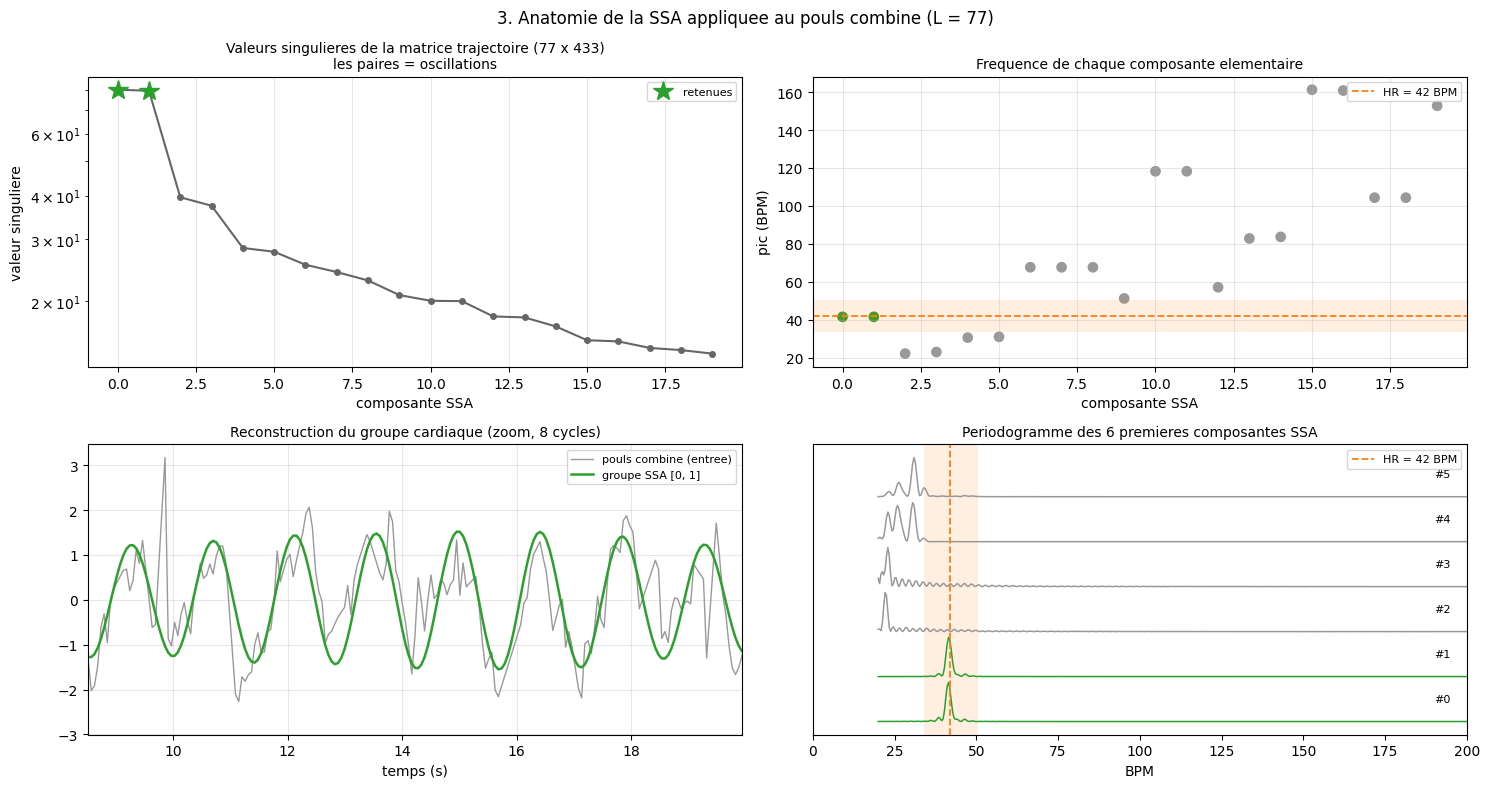

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8))

ax = axes[0, 0]
ax.semilogy(np.arange(SSA_N_COMP), sv_demo[:SSA_N_COMP], ".-", color="0.4", ms=8)
ax.semilogy(keep_demo, sv_demo[keep_demo], "*", ms=15, color="C2", label="retenues")
ax.set_xlabel("composante SSA")
ax.set_ylabel("valeur singuliere")
ax.set_title(f"Valeurs singulieres de la matrice trajectoire ({L_SSA} x {K_SSA})\n"
             "les paires = oscillations", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
col = ["C2" if i in set(keep_demo.tolist()) else "0.6" for i in range(SSA_N_COMP)]
ax.scatter(np.arange(SSA_N_COMP), peaks_demo, c=col, s=45)
ax.axhline(hr, color="C1", ls="--", lw=1.3, label=f"HR = {hr:.0f} BPM")
ax.axhspan(*band.effective_bpm_range, color="C1", alpha=0.12, lw=0)
ax.set_xlabel("composante SSA")
ax.set_ylabel("pic (BPM)")
ax.set_title("Frequence de chaque composante elementaire", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
mid = 0.5 * (u_time[0] + u_time[-1])
half = 2.0 * 60.0 / hr
ax.plot(u_time, z(y_comb_u), lw=1.0, color="0.6", label="pouls combine (entree)")
ax.plot(u_time, z(recon_demo[keep_demo].sum(axis=0)), lw=1.8, color="C2",
        label=f"groupe SSA {keep_demo.tolist()}")
ax.set_xlim(mid - 2 * half, mid + 2 * half)
ax.set_xlabel("temps (s)")
ax.set_title("Reconstruction du groupe cardiaque (zoom, 8 cycles)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
for k in range(min(6, SSA_N_COMP)):
    P = spectrum(recon_demo[k], u_time)
    ax.plot(bpm_axis, P / (P.max() + 1e-12) + k * 1.15,
            lw=1.1, color="C2" if k in set(keep_demo.tolist()) else "0.6")
    ax.text(195, k * 1.15 + 0.5, f"#{k}", fontsize=8, ha="right")
mark_hr(ax)
ax.set_xlim(0, 200)
ax.set_yticks([])
ax.set_xlabel("BPM")
ax.set_title("Periodogramme des 6 premieres composantes SSA", fontsize=10)
ax.legend(fontsize=8)

fig.suptitle(f"3. Anatomie de la SSA appliquee au pouls combine (L = {L_SSA})",
             fontsize=12)
fig.tight_layout()
plt.show()

## 4. Les quatre approches

Toutes produisent un pouls sur `u_time`, ce qui rend les phases directement
superposables.

- **0** : `y_comb` -> interpolation -> Hilbert, **sans aucun filtrage**. Meme
  le temoin passe par `u_time` : la transformee de Hilbert exige elle aussi un
  echantillonnage regulier.
- **1** : `y_comb` -> passe-bande FIR (`spatio_temporal_filter`, memes coupures
  que `AbstractUniformTraceSource.filtered_signal`) -> Hilbert.
- **2** : `y_comb` -> interpolation -> SSA -> Hilbert. Pas de FIR : la SSA a
  deja produit une composante a bande etroite, et enchainer les deux
  reviendrait a mesurer le filtre plutot que la SSA.
- **3a** : les `n_ch` canaux -> **une seule** matrice trajectoire empilee
  `(n_ch*L, K)` -> SVD -> paire cardiaque -> reconstruction par canal ->
  1re composante principale -> Hilbert.
- **3b** : chaque canal debruite par sa propre SSA ->
  `OptimizedSpectralCombination` sur les canaux debruites -> Hilbert.

In [8]:
# --- Passe-bande de la chaine actuelle (approche 1 uniquement) ---------------
_NYQ = 0.5 * aligner.fs
_LO_BPM, _HI_BPM = band.effective_bpm_range
_LOW = (_LO_BPM / 60.0) / _NYQ
_HIGH = min((_HI_BPM / 60.0) / _NYQ, 0.99)


def bandpass_pulse(y, tt):
    """Passe-bande cardiaque : interpolation sur `u_time` puis FIR, exactement
    comme `filtered_signal`, qui filtre `interpolated_signal`."""
    yu = np.interp(u_time, tt, np.asarray(y, dtype=float))
    return spatio_temporal_filter(yu[:, None], 0.0, _LOW, _HIGH,
                                  aligner.fs, None)[:, 0]


EDGE_FRAC = 0.2
_m = int(EDGE_FRAC * u_time.size)
core = np.zeros(u_time.size, dtype=bool)
core[_m:u_time.size - _m] = True
_ntaps = min(max(int(round(4.0 * aligner.fs / _LOW)), 31),
             max(3, (u_time.size // 3) | 1))
print(f"FIR : ~{_ntaps} taps = {_ntaps / aligner.fs:.1f} s sur "
      f"{u_time[-1] - u_time[0]:.1f} s   |   SSA : L = {L_SSA} = "
      f"{L_SSA / aligner.fs:.1f} s")
print(f"-> la SSA regarde une fenetre {_ntaps / L_SSA:.1f}x plus courte que le FIR, "
      "et ne cree pas de transitoire de bord.")


def analytic_phase(y):
    """(phase repliee, BPM instantane) d'une trace a bande etroite sur u_time."""
    y = np.asarray(y, dtype=float)
    an = hilbert(y - y.mean())
    ph = np.unwrap(np.angle(an))
    f_inst = np.gradient(ph, u_time) / (2 * np.pi)
    win = int(round(aligner.fs / f0)) | 1
    if 1 < win < f_inst.size:
        f_inst = medfilt(f_inst, win)
    return np.mod(ph, 2 * np.pi), f_inst * 60.0

FIR : ~169 taps = 9.5 s sur 28.4 s   |   SSA : L = 77 = 4.3 s
-> la SSA regarde une fenetre 2.2x plus courte que le FIR, et ne cree pas de transitoire de bord.


In [9]:
# ============================ APPROCHE 0 (temoin) ============================
# Aucun filtrage : la combinaison optimisee, simplement interpolee sur u_time.
t0 = time.perf_counter()
y0 = fix_sign(y_comb_u, u_time)
c0 = time.perf_counter() - t0
print(f"0  combinaison seule (sans filtre)   : {c0:.2f} s")

# ============================ APPROCHE 1 =====================================
t0 = time.perf_counter()
y1 = fix_sign(bandpass_pulse(y_comb, t), u_time)
c1 = time.perf_counter() - t0
print(f"1  combinaison -> FIR                : {c1:.2f} s")

# ============================ APPROCHE 2 =====================================
t0 = time.perf_counter()
y2_raw, d2 = ssa_denoise(y_comb_u, L_SSA, u_time)
y2 = fix_sign(y2_raw, u_time)
c2 = time.perf_counter() - t0
print(f"2  combinaison -> SSA                : {c2:.2f} s   "
      f"groupe {d2['keep'].tolist()}")

0  combinaison seule (sans filtre)   : 0.00 s
1  combinaison -> FIR                : 0.04 s
2  combinaison -> SSA                : 0.04 s   groupe [0, 1]


In [10]:
# ============================ APPROCHE 3a ====================================
# M-SSA : une seule matrice trajectoire empilant les n_ch canaux.
def mssa_denoise(chan, L, tt, tol_bpm=None, n_comp=None):
    """M-SSA sur `chan` (n_ch, N). Renvoie (canaux debruites, diagnostics).

    Les matrices trajectoire des canaux sont empilees VERTICALEMENT : la SVD
    voit alors un sous-espace temporel PARTAGE, ce qui est exactement
    l'hypothese physique -- un meme pouls vu par plusieurs canaux, a des
    amplitudes et des retards differents.
    """
    tol = BAND_FRAC * hr if tol_bpm is None else tol_bpm
    n_ch_, N_ = chan.shape
    H = np.vstack([hankel_matrix(c, L) for c in chan])          # (n_ch*L, K)
    Uh, sh, Vth = np.linalg.svd(H, full_matrices=False)
    n = int(min(n_comp or SSA_N_COMP, sh.size))

    # Reconstruction elementaire, canal par canal.
    recon = np.empty((n, n_ch_, N_))
    for k in range(n):
        Mk = sh[k] * np.outer(Uh[:, k], Vth[k])
        for c in range(n_ch_):
            recon[k, c] = diagonal_average(Mk[c * L:(c + 1) * L])

    # Regroupement sur la MOYENNE des canaux : une composante M-SSA est
    # cardiaque ou ne l'est pas, c'est une propriete du mode partage.
    peaks = np.array([band_score(recon[k].mean(axis=0), tt)[1] for k in range(n)])
    fracs = np.array([band_score(recon[k].mean(axis=0), tt)[0] for k in range(n)])
    keep = np.where(np.abs(peaks - hr) <= tol)[0]
    if keep.size == 0:
        keep = np.argsort(fracs)[::-1][:2]
    keep = np.sort(keep)
    return recon[keep].sum(axis=0), {
        "sv": sh, "keep": keep, "peaks": peaks, "fracs": fracs, "H_shape": H.shape,
    }


chan_u = np.stack([np.interp(u_time, t, U[:, i]) for i in channels])   # (n_ch, Nu)
t0 = time.perf_counter()
R3a, d3a = mssa_denoise(chan_u, L_SSA, u_time)
# Les canaux debruites sont, par construction, quasi de rang 2 : leur premiere
# composante principale EST l'oscillation partagee.
Uc, Sc, Vtc = np.linalg.svd(R3a - R3a.mean(axis=1, keepdims=True),
                            full_matrices=False)
y3a = fix_sign(Vtc[0] * Sc[0], u_time)
c3a = time.perf_counter() - t0
print(f"3a M-SSA {d3a['H_shape']} -> 1re PC : {c3a:.2f} s   "
      f"groupe {d3a['keep'].tolist()}, "
      f"part de variance de la 1re PC = {Sc[0] ** 2 / (Sc ** 2).sum():.1%}")

# ============================ APPROCHE 3b ====================================
t0 = time.perf_counter()
chan_den = np.stack([ssa_denoise(c, L_SSA, u_time)[0] for c in chan_u])
print(f"3b SSA canal par canal ({n_ch} canaux) :")
y3b_raw, res3b = optimized_pulse(chan_den.T, None, u_time, "canaux debruites")
y3b = fix_sign(y3b_raw, u_time)
c3b = time.perf_counter() - t0
print(f"   total : {c3b:.2f} s")

3a M-SSA (539, 433) -> 1re PC : 0.30 s   groupe [0, 1, 11, 12, 18], part de variance de la 1re PC = 68.7%


3b SSA canal par canal (7 canaux) :


  [canaux debruites] 7 candidates [0, 1, 2, 3, 4, 5, 6], objectif -1.8739 (5.0 s)
   total : 5.28 s


## 5. Ce que la M-SSA fait aux canaux (approche 3a)

Avant/apres, canal par canal. Chaque canal est un vecteur singulier de la SVD
rang 100 : deja une combinaison de ~1e4 pixels, mais encore bruite.

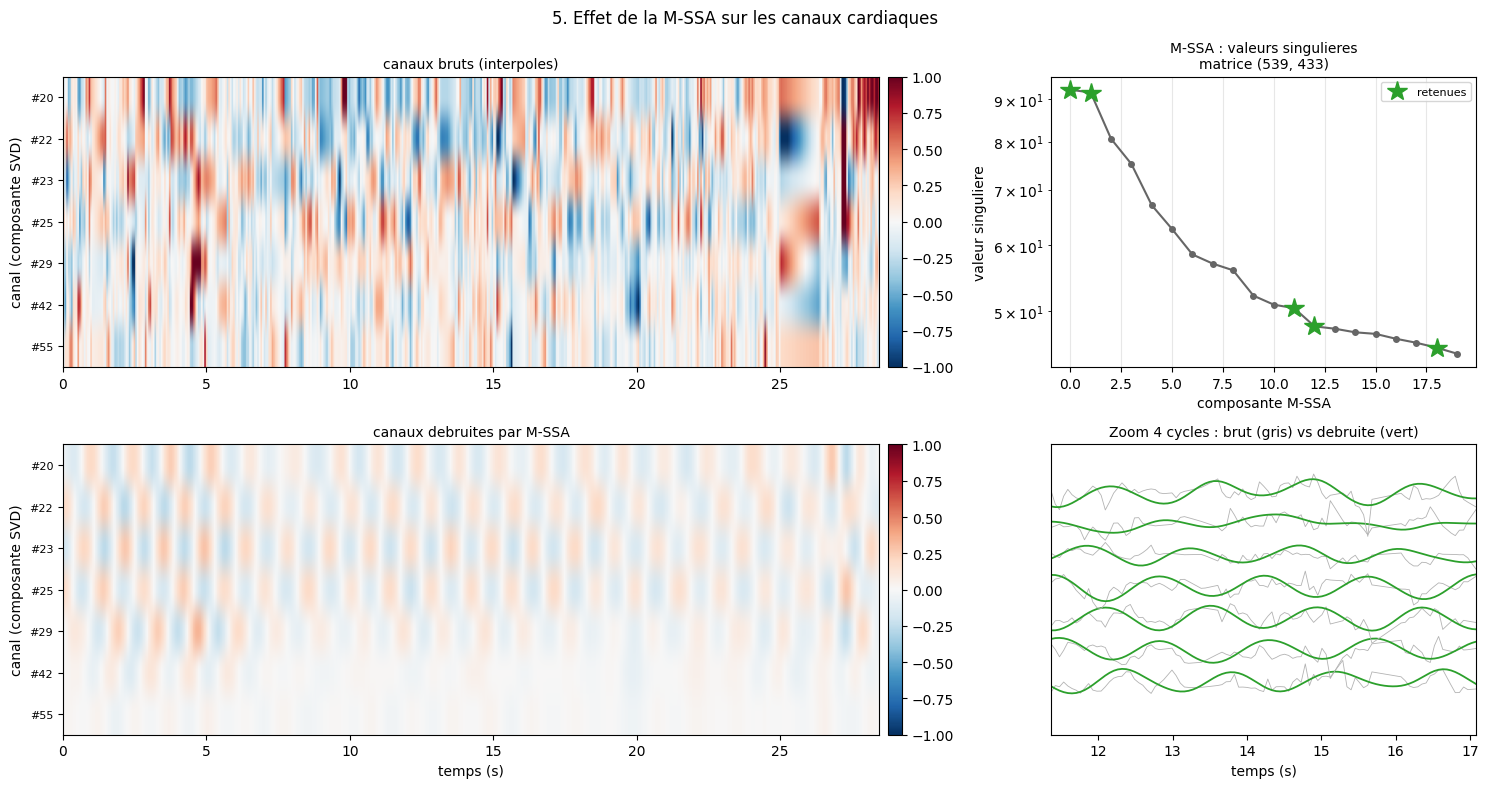

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 8),
                         gridspec_kw={"width_ratios": [2.0, 1.0]})

vmax = np.percentile(np.abs(chan_u), 99)
for row, (M, name) in enumerate([(chan_u, "canaux bruts (interpoles)"),
                                 (R3a, "canaux debruites par M-SSA")]):
    ax = axes[row, 0]
    im = ax.imshow(M / vmax, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1,
                   extent=[u_time[0], u_time[-1], n_ch - 0.5, -0.5])
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
    ax.set_yticks(range(n_ch))
    ax.set_yticklabels([f"#{c}" for c in channels], fontsize=8)
    ax.set_ylabel("canal (composante SVD)")
    ax.set_title(name, fontsize=10)
    if row:
        ax.set_xlabel("temps (s)")

ax = axes[0, 1]
ax.semilogy(np.arange(len(d3a["sv"][:SSA_N_COMP])), d3a["sv"][:SSA_N_COMP],
            ".-", color="0.4", ms=8)
ax.semilogy(d3a["keep"], d3a["sv"][d3a["keep"]], "*", ms=15, color="C2",
            label="retenues")
ax.set_xlabel("composante M-SSA")
ax.set_ylabel("valeur singuliere")
ax.set_title(f"M-SSA : valeurs singulieres\nmatrice {d3a['H_shape']}", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
for c in range(n_ch):
    ax.plot(u_time, z(chan_u[c]) + 4 * c, lw=0.6, color="0.7")
    ax.plot(u_time, z(R3a[c]) + 4 * c, lw=1.3, color="C2")
ax.set_xlim(mid - half, mid + half)
ax.set_yticks([])
ax.set_xlabel("temps (s)")
ax.set_title("Zoom 4 cycles : brut (gris) vs debruite (vert)", fontsize=10)

fig.suptitle("5. Effet de la M-SSA sur les canaux cardiaques", fontsize=12)
fig.tight_layout()
plt.show()

## 6. Les quatre pouls

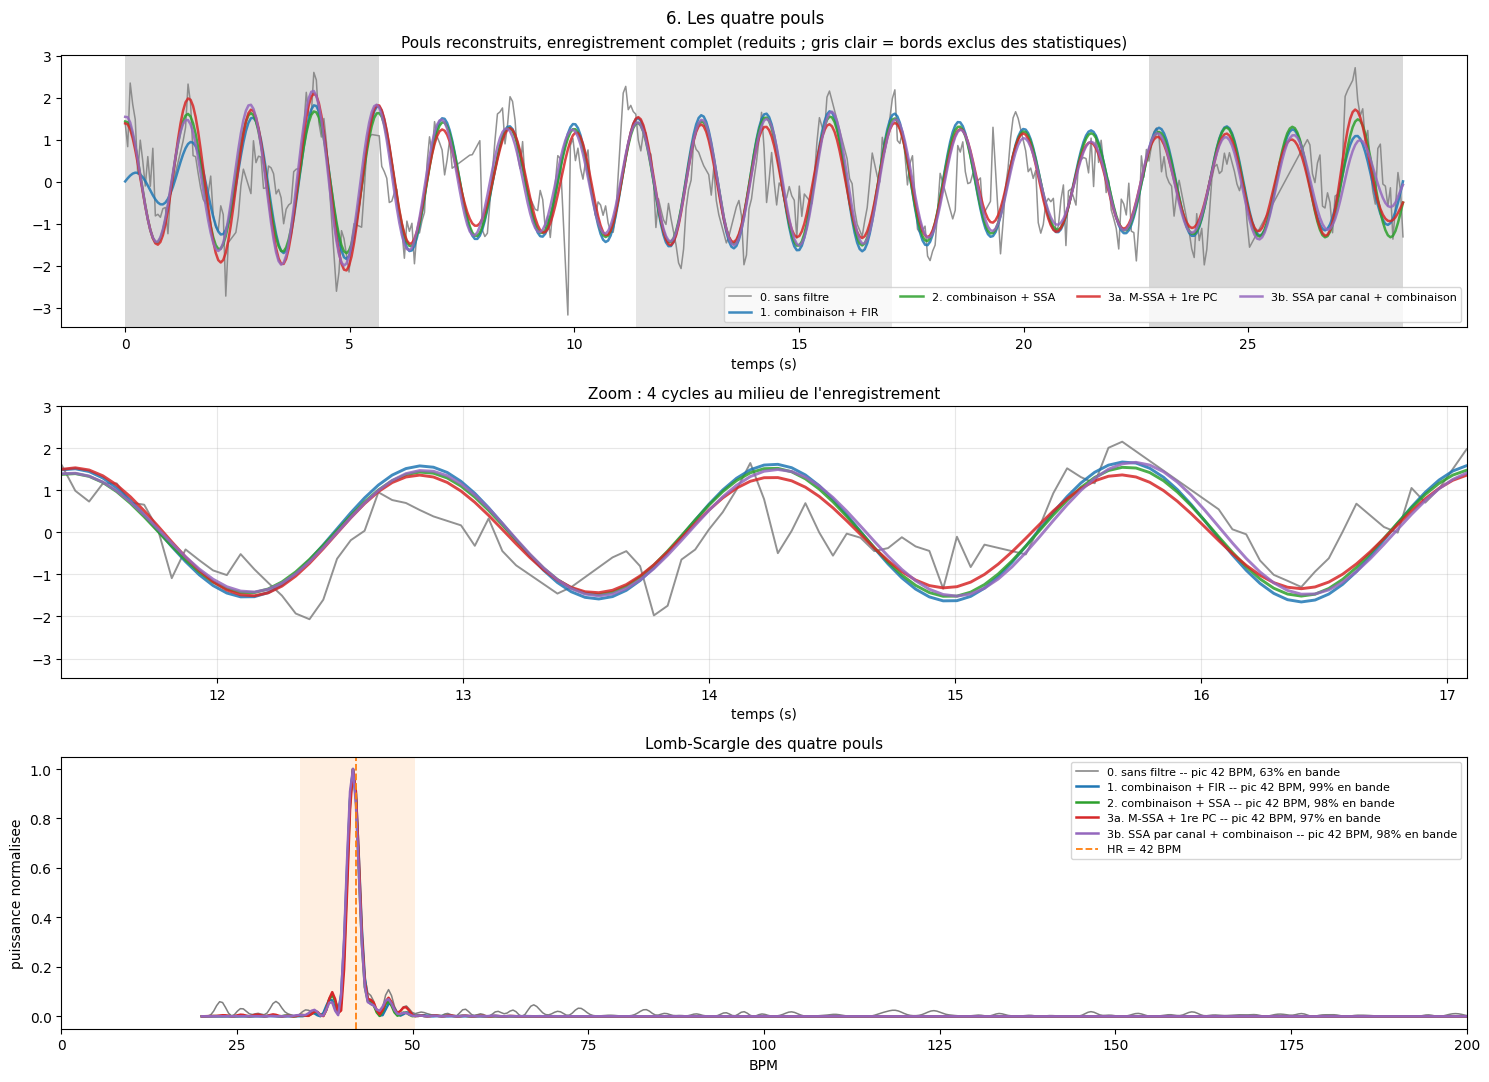

In [12]:
PULSES = {
    "0. sans filtre": (y0, "C7", 1.1),
    "1. combinaison + FIR": (y1, "C0", 1.8),
    "2. combinaison + SSA": (y2, "C2", 1.8),
    "3a. M-SSA + 1re PC": (y3a, "C3", 1.8),
    "3b. SSA par canal + combinaison": (y3b, "C4", 1.8),
}
REFERENCE = "1. combinaison + FIR"     # la chaine actuelle sert de reference

fig, axes = plt.subplots(3, 1, figsize=(15, 11))

for name, (y, c, lw) in PULSES.items():
    axes[0].plot(u_time, z(y), lw=lw, color=c, alpha=0.85, label=name)
axes[0].axvspan(mid - half, mid + half, color="0.9", lw=0, zorder=0)
axes[0].axvspan(u_time[0], u_time[_m], color="0.85", lw=0, zorder=0)
axes[0].axvspan(u_time[-_m - 1], u_time[-1], color="0.85", lw=0, zorder=0)
axes[0].set_title("Pouls reconstruits, enregistrement complet (reduits ; gris "
                  "clair = bords exclus des statistiques)", fontsize=11)
axes[0].set_xlabel("temps (s)")
axes[0].legend(fontsize=8, ncol=4)

for name, (y, c, lw) in PULSES.items():
    axes[1].plot(u_time, z(y), lw=lw + 0.3, color=c, alpha=0.85)
axes[1].set_xlim(mid - half, mid + half)
axes[1].set_title(f"Zoom : 4 cycles au milieu de l'enregistrement", fontsize=11)
axes[1].set_xlabel("temps (s)")
axes[1].grid(alpha=0.3)

for name, (y, c, lw) in PULSES.items():
    P = spectrum(y, u_time)
    fr, pk = band_score(y, u_time)
    axes[2].plot(bpm_axis, P / (P.max() + 1e-12), lw=lw, color=c,
                 label=f"{name} -- pic {pk:.0f} BPM, {fr:.0%} en bande")
mark_hr(axes[2])
axes[2].set_xlim(0, 200)
axes[2].set_xlabel("BPM")
axes[2].set_ylabel("puissance normalisee")
axes[2].set_title("Lomb-Scargle des quatre pouls", fontsize=11)
axes[2].legend(fontsize=8)

fig.suptitle("6. Les quatre pouls", fontsize=12)
fig.tight_layout()
plt.show()

In [13]:
names = list(PULSES)
M = np.array([[np.corrcoef(PULSES[a][0][core], PULSES[b][0][core])[0, 1]
               for b in names] for a in names])
print("Correlation de Pearson (bords exclus, sans decalage) :")
display(pd.DataFrame(M, index=names, columns=names).round(3))


def best_lag(a, b):
    """Decalage du max de |correlation croisee|, borne a +/- un demi-cycle.

    La reduction se fait APRES avoir coupe les bords : reduire d'abord puis
    trancher laisserait au segment central une variance != 1 et |xc| pourrait
    depasser 1.
    """
    xa, xb = z(np.asarray(a)[core]), z(np.asarray(b)[core])
    xc = np.correlate(xa, xb, mode="full") / len(xa)
    lags = np.arange(-len(xa) + 1, len(xa)) * (u_time[1] - u_time[0])
    keep = np.abs(lags) <= 0.5 * 60.0 / hr
    j = int(np.argmax(np.abs(xc[keep])))
    return lags[keep][j], xc[keep][j]


print(f"\nDecalage par rapport a '{REFERENCE}' (> 0 : en retard sur elle) :")
for name in names:
    if name == REFERENCE:
        continue
    lag, val = best_lag(PULSES[REFERENCE][0], PULSES[name][0])
    print(f"  {name:<34s} {lag * 1e3:+7.0f} ms ({lag * f0 * 360:+6.1f} deg), "
          f"|xc| = {abs(val):.3f}")

Correlation de Pearson (bords exclus, sans decalage) :


,0. sans filtre,1. combinaison + FIR,2. combinaison + SSA,3a. M-SSA + 1re PC,3b. SSA par canal + combinaison
0. sans filtre,1.000,0.681,0.685,0.705,0.685
1. combinaison + FIR,0.681,1.000,1.000,0.992,0.990
2. combinaison + SSA,0.685,1.000,1.000,0.992,0.990
3a. M-SSA + 1re PC,0.705,0.992,0.992,1.000,0.981
3b. SSA par canal + combinaison,0.685,0.990,0.990,0.981,1.000



Decalage par rapport a '1. combinaison + FIR' (> 0 : en retard sur elle) :
  0. sans filtre                          +0 ms (  +0.0 deg), |xc| = 0.681
  2. combinaison + SSA                    +0 ms (  +0.0 deg), |xc| = 1.000
  3a. M-SSA + 1re PC                      +0 ms (  +0.0 deg), |xc| = 0.992
  3b. SSA par canal + combinaison         +0 ms (  +0.0 deg), |xc| = 0.990


## 7. Phase et rythme cardiaque instantane

In [14]:
PHASES = {}
for name, (y, c, lw) in PULSES.items():
    ph, bpm = analytic_phase(y)
    PHASES[name] = (ph, bpm, c, lw)

print(f"{'approche':<34s} {'HR med':>8s} {'IQR':>7s} {'etendue':>16s} "
      f"{'en bande':>9s}")
for name, (ph, bpm, c, lw) in PHASES.items():
    b = bpm[core]
    fr, _ = band_score(PULSES[name][0], u_time)
    print(f"{name:<34s} {np.median(b):8.2f} "
          f"{np.percentile(b, 75) - np.percentile(b, 25):7.2f} "
          f"{b.min():7.1f}-{b.max():<8.1f} {100 * fr:8.1f} %")
print(f"{'HR visit_data.csv':<34s} {hr:8.2f}")

approche                             HR med     IQR          etendue  en bande
0. sans filtre                        48.22   17.22    12.7-93.2         63.2 %
1. combinaison + FIR                  41.79    0.95    39.6-42.2         99.3 %
2. combinaison + SSA                  41.72    0.75    39.8-42.5         97.8 %
3a. M-SSA + 1re PC                    41.30    1.39    39.2-44.3         97.1 %
3b. SSA par canal + combinaison       41.46    0.71    39.9-42.3         98.3 %
HR visit_data.csv                     42.00


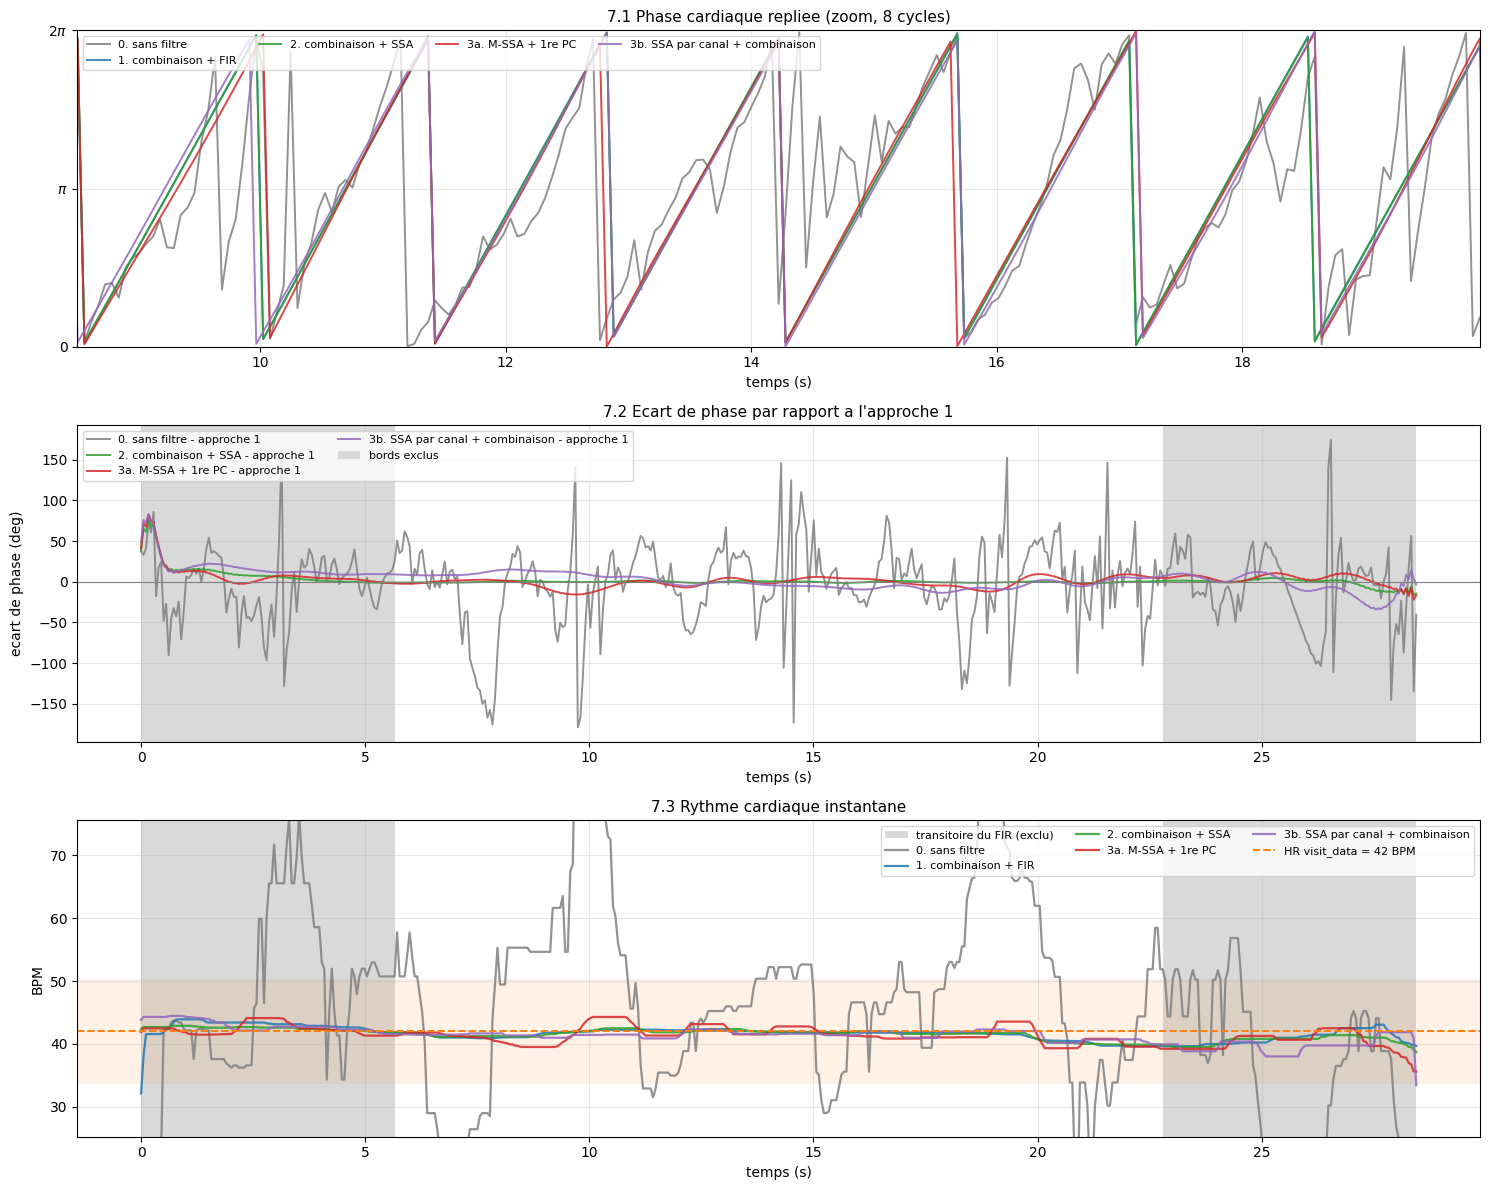

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

ax = axes[0]
for name, (ph, bpm, c, lw) in PHASES.items():
    ax.plot(u_time, ph, lw=1.4, color=c, alpha=0.85, label=name)
ax.set_xlim(mid - 2 * half, mid + 2 * half)
ax.set_ylim(0, 2 * np.pi)
ax.set_yticks([0, np.pi, 2 * np.pi])
ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
ax.set_xlabel("temps (s)")
ax.set_title("7.1 Phase cardiaque repliee (zoom, 8 cycles)", fontsize=11)
ax.legend(fontsize=8, ncol=4)
ax.grid(alpha=0.3)

# Ecart de phase a la chaine actuelle, ramene dans [-pi, pi].
ax = axes[1]
ph_ref = PHASES[REFERENCE][0]
for name in names:
    if name == REFERENCE:
        continue
    d = np.angle(np.exp(1j * (PHASES[name][0] - ph_ref)))
    ax.plot(u_time, np.degrees(d), lw=1.4, color=PHASES[name][2], alpha=0.85,
            label=f"{name} - approche 1")
ax.axhline(0, color="0.5", lw=0.8)
ax.axvspan(u_time[0], u_time[_m], color="0.85", lw=0, zorder=0)
ax.axvspan(u_time[-_m - 1], u_time[-1], color="0.85", lw=0, zorder=0,
           label="bords exclus")
ax.set_xlabel("temps (s)")
ax.set_ylabel("ecart de phase (deg)")
ax.set_title("7.2 Ecart de phase par rapport a l'approche 1", fontsize=11)
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.3)

ax = axes[2]
ax.axvspan(u_time[0], u_time[_m], color="0.85", lw=0, zorder=0)
ax.axvspan(u_time[-_m - 1], u_time[-1], color="0.85", lw=0, zorder=0,
           label="transitoire du FIR (exclu)")
for name, (ph, bpm, c, lw) in PHASES.items():
    ax.plot(u_time, bpm, lw=1.6, color=c, alpha=0.85, label=name)
ax.axhline(hr, color="C1", lw=1.4, ls="--", label=f"HR visit_data = {hr:.0f} BPM")
ax.axhspan(*band.effective_bpm_range, color="C1", alpha=0.10, lw=0)
ax.set_ylim(0.6 * hr, 1.8 * hr)
ax.set_xlabel("temps (s)")
ax.set_ylabel("BPM")
ax.set_title("7.3 Rythme cardiaque instantane", fontsize=11)
ax.legend(fontsize=8, ncol=3, loc="upper right")
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

### 7.4 La phase de Hilbert est-elle seulement legitime ?

La phase analytique ne veut dire quelque chose que si le signal est a **bande
etroite** : c'est la condition de Bedrosian/Nuttall. Le test le plus direct est
que la frequence instantanee $\dot\varphi/2\pi$ doit rester **positive** -- une
phase qui recule en arriere n'a pas de sens pour un pouls. On mesure donc, sur
la frequence instantanee **brute** (avant le filtre median, qui masquerait
justement ces accidents) :

- la part d'echantillons a frequence **negative** ;
- la part d'echantillons **hors de la bande physiologique**.

In [16]:
def inst_freq_raw(y):
    """Frequence instantanee BRUTE (BPM), sans filtre median : c'est elle qui
    revele les violations de la condition de bande etroite."""
    y = np.asarray(y, dtype=float)
    ph = np.unwrap(np.angle(hilbert(y - y.mean())))
    return np.gradient(ph, u_time) / (2 * np.pi) * 60.0


lo_b, hi_b = band.effective_bpm_range
diag_rows = []
for name, (y, c, lw) in PULSES.items():
    fr_raw = inst_freq_raw(y)[core]
    diag_rows.append({
        "approche": name,
        "f<0_%": 100 * (fr_raw < 0).mean(),
        "hors_bande_%": 100 * ((fr_raw < lo_b) | (fr_raw > hi_b)).mean(),
        "f_brute_min": fr_raw.min(),
        "f_brute_max": fr_raw.max(),
        "IQR_brute": np.percentile(fr_raw, 75) - np.percentile(fr_raw, 25),
    })
diag = pd.DataFrame(diag_rows).set_index("approche")
display(diag.round(2))
print(f"bande physiologique : {lo_b:.1f} - {hi_b:.1f} BPM")
print("\n-> une frequence instantanee negative signifie que la phase RECULE : "
      "le signal\n   n'est pas a bande etroite et la phase de Hilbert n'y est "
      "pas interpretable.")

,f<0_%,hors_bande_%,f_brute_min,f_brute_max,IQR_brute
approche,,,,,
0. sans filtre,18.89,87.3,-157.47,342.66,63.10
1. combinaison + FIR,0.00,0.0,39.32,42.49,0.98
2. combinaison + SSA,0.00,0.0,39.69,42.80,0.86
3a. M-SSA + 1re PC,0.00,0.0,37.25,47.25,2.22
3b. SSA par canal + combinaison,0.00,0.0,38.00,45.08,1.43


bande physiologique : 33.6 - 50.4 BPM

-> une frequence instantanee negative signifie que la phase RECULE : le signal
   n'est pas a bande etroite et la phase de Hilbert n'y est pas interpretable.


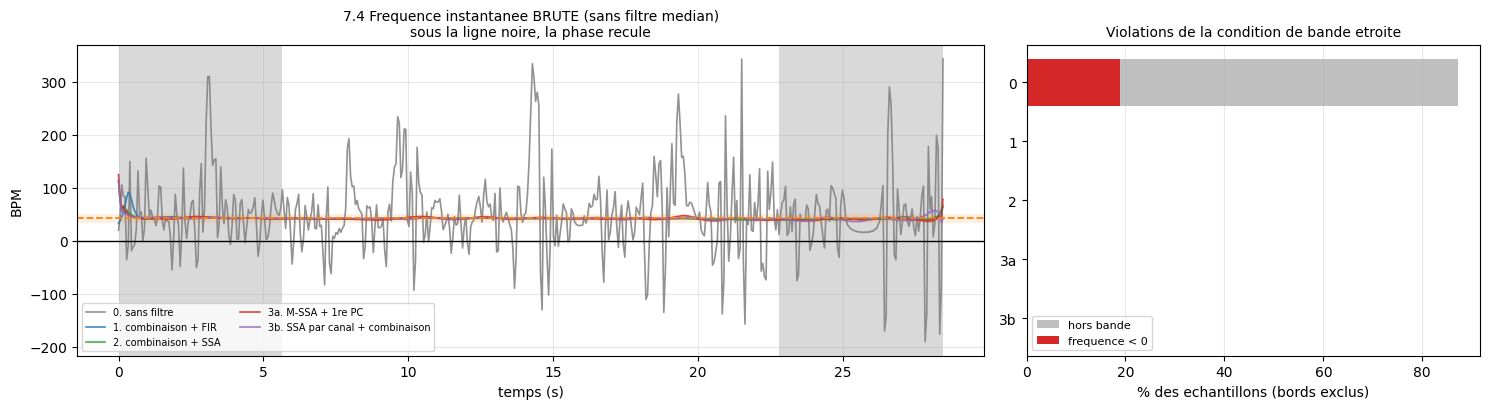

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.2),
                         gridspec_kw={"width_ratios": [2.0, 1.0]})

ax = axes[0]
for name, (y, c, lw) in PULSES.items():
    ax.plot(u_time, inst_freq_raw(y), lw=1.2, color=c, alpha=0.85, label=name)
ax.axhline(0, color="k", lw=1.0)
ax.axhline(hr, color="C1", ls="--", lw=1.3)
ax.axhspan(lo_b, hi_b, color="C1", alpha=0.12, lw=0)
ax.axvspan(u_time[0], u_time[_m], color="0.85", lw=0, zorder=0)
ax.axvspan(u_time[-_m - 1], u_time[-1], color="0.85", lw=0, zorder=0)
ax.set_xlabel("temps (s)")
ax.set_ylabel("BPM")
ax.set_title("7.4 Frequence instantanee BRUTE (sans filtre median)\n"
             "sous la ligne noire, la phase recule", fontsize=10)
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)

ax = axes[1]
bars = ax.barh(range(len(diag)), diag["hors_bande_%"], color="0.75",
               label="hors bande")
ax.barh(range(len(diag)), diag["f<0_%"], color="C3", label="frequence < 0")
ax.set_yticks(range(len(diag)))
ax.set_yticklabels([n.split(".")[0] for n in diag.index])
ax.invert_yaxis()
ax.set_xlabel("% des echantillons (bords exclus)")
ax.set_title("Violations de la condition de bande etroite", fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis="x")

fig.tight_layout()
plt.show()

## 8. Sensibilite a la fenetre de plongement `L`

Le seul parametre libre des approches SSA. Trop court, la fenetre ne separe pas
le fondamental de la derive ; trop long, il ne reste plus assez de colonnes
$K = N - L + 1$ pour que le moyennage anti-diagonal debruite quoi que ce soit --
et les bords se degradent. On balaie de 1 a 8 cycles.

,approche,cycles,L,K,n_comp_groupe,pic_BPM,en_bande_%,HR_med,HR_IQR,corr_avec_L_ref
0,2,1.0,27,483,2,41.507,90.499,41.005,4.244,0.958
1,3a,1.0,27,483,7,41.507,71.980,18.680,15.094,0.596
2,2,2.0,51,459,2,41.507,96.986,41.440,1.222,0.995
3,3a,2.0,51,459,5,41.507,38.113,46.482,11.081,0.570
4,2,3.0,77,433,2,41.507,97.783,41.723,0.748,1.000
5,3a,3.0,77,433,5,41.507,97.109,41.301,1.393,1.000
6,2,5.0,129,381,2,41.507,97.570,41.762,0.544,0.996
7,3a,5.0,129,381,9,41.507,96.401,40.999,2.538,0.987
8,2,8.0,205,305,4,41.507,97.042,41.516,1.473,0.990
9,3a,8.0,205,305,5,41.507,97.926,41.677,1.031,0.990


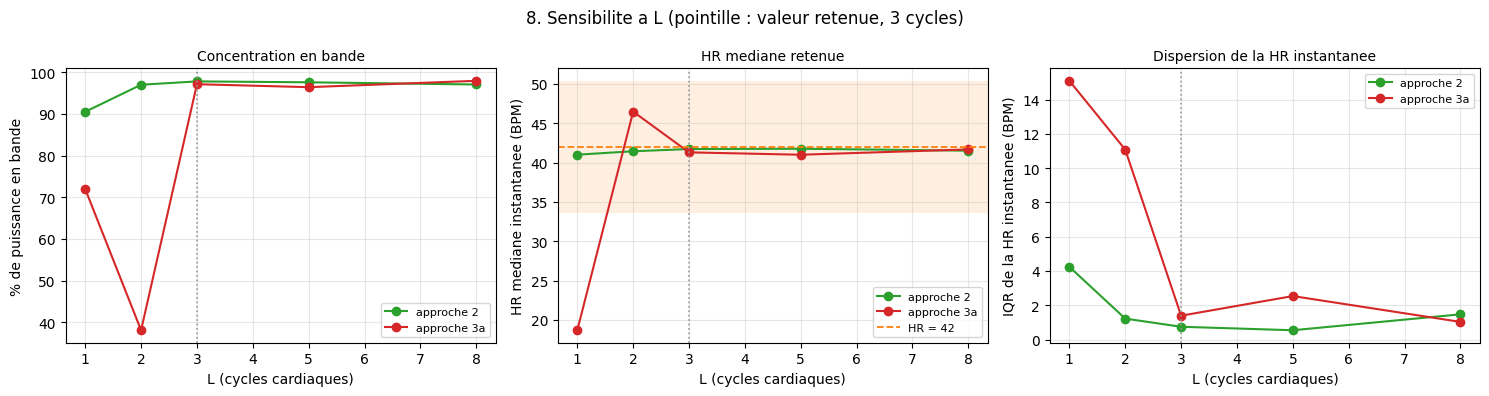

In [18]:
rows = []
for cyc in SSA_CYCLES_SWEEP:
    L = int(round(cyc * aligner.fs / f0)) | 1
    if u_time.size - L + 1 < L:
        print(f"L = {L} ({cyc:.0f} cycles) ignore : K < L")
        continue
    y2c, d2c = ssa_denoise(y_comb_u, L, u_time)
    y2c = fix_sign(y2c, u_time)
    R3c, d3c = mssa_denoise(chan_u, L, u_time)
    _, Sc_, Vtc_ = np.linalg.svd(R3c - R3c.mean(axis=1, keepdims=True),
                                 full_matrices=False)
    y3c = fix_sign(Vtc_[0] * Sc_[0], u_time)
    for tag, y, d in [("2", y2c, d2c), ("3a", y3c, d3c)]:
        fr, pk = band_score(y, u_time)
        _, bpm_c = analytic_phase(y)
        rows.append({
            "approche": tag, "cycles": cyc, "L": L, "K": u_time.size - L + 1,
            "n_comp_groupe": len(d["keep"]),
            "pic_BPM": pk, "en_bande_%": 100 * fr,
            "HR_med": np.median(bpm_c[core]),
            "HR_IQR": np.percentile(bpm_c[core], 75) - np.percentile(bpm_c[core], 25),
            "corr_avec_L_ref": np.corrcoef(
                y[core], (y2 if tag == "2" else y3a)[core])[0, 1],
        })
sweep = pd.DataFrame(rows)
display(sweep.round(3))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for tag, c in [("2", "C2"), ("3a", "C3")]:
    sub = sweep[sweep.approche == tag]
    axes[0].plot(sub.cycles, sub["en_bande_%"], "o-", color=c, label=f"approche {tag}")
    # HR MEDIANE plutot que le pic Lomb-Scargle : le pic reste colle a 41,5 BPM
    # quel que soit L (meme grille de frequences), il ne revele donc aucun
    # decrochage. La HR mediane instantanee, elle, le montre immediatement.
    axes[1].plot(sub.cycles, sub.HR_med, "o-", color=c, label=f"approche {tag}")
    axes[2].plot(sub.cycles, sub.HR_IQR, "o-", color=c, label=f"approche {tag}")
axes[0].set_ylabel("% de puissance en bande")
axes[1].axhline(hr, color="C1", ls="--", lw=1.3, label=f"HR = {hr:.0f}")
axes[1].axhspan(*band.effective_bpm_range, color="C1", alpha=0.12, lw=0)
axes[1].set_ylabel("HR mediane instantanee (BPM)")
axes[2].set_ylabel("IQR de la HR instantanee (BPM)")
for ax, ttl in zip(axes, ["Concentration en bande", "HR mediane retenue",
                          "Dispersion de la HR instantanee"]):
    ax.axvline(SSA_CYCLES, color="0.6", ls=":", lw=1.2)
    ax.set_xlabel("L (cycles cardiaques)")
    ax.set_title(ttl, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle(f"8. Sensibilite a L (pointille : valeur retenue, "
             f"{SSA_CYCLES:.0f} cycles)", fontsize=12)
fig.tight_layout()
plt.show()

## 9. Bilan chiffre

In [19]:
summary = pd.DataFrame([{
    "approche": name,
    "pic_LS_BPM": band_score(y, u_time)[1],
    "en_bande_%": 100 * band_score(y, u_time)[0],
    "HR_med_BPM": np.median(PHASES[name][1][core]),
    "HR_IQR_BPM": (np.percentile(PHASES[name][1][core], 75)
                   - np.percentile(PHASES[name][1][core], 25)),
    "ecart_HR_ref": np.median(PHASES[name][1][core]) - hr,
    "corr_approche_1": np.corrcoef(y1[core], y[core])[0, 1],
    "cout_s": cost,
} for (name, (y, c, lw)), cost in zip(PULSES.items(), [c0, c1, c2, c3a, c3b])
]).set_index("approche")
summary = summary.join(diag[["f<0_%", "hors_bande_%"]])
display(summary.round(3))
print(f"HR de reference (visit_data.csv) : {hr:.0f} BPM")

,pic_LS_BPM,en_bande_%,HR_med_BPM,HR_IQR_BPM,ecart_HR_ref,corr_approche_1,cout_s,f<0_%,hors_bande_%
approche,,,,,,,,,
0. sans filtre,41.507,63.222,48.218,17.220,6.218,0.681,0.000,18.893,87.296
1. combinaison + FIR,41.507,99.322,41.793,0.949,-0.207,1.000,0.038,0.000,0.000
2. combinaison + SSA,41.507,97.783,41.723,0.748,-0.277,1.000,0.044,0.000,0.000
3a. M-SSA + 1re PC,41.507,97.109,41.301,1.393,-0.699,0.992,0.302,0.000,0.000
3b. SSA par canal + combinaison,41.507,98.282,41.461,0.715,-0.539,0.990,5.284,0.000,0.000


HR de reference (visit_data.csv) : 42 BPM


## 10. Lecture

### D'abord le temoin : filtrer n'est pas optionnel

L'approche 0 -- Hilbert applique directement a la combinaison optimisee --
**echoue franchement** :

- HR mediane **48,2 BPM** contre 42,0 au tonometre, IQR **17,2 BPM**, etendue
  12,7 a 93,2 BPM ;
- sur la frequence instantanee brute, **18,9 % des echantillons sont negatifs**
  et **87,3 % hors bande physiologique**, avec des excursions de -157 a
  +343 BPM ;
- correlation de seulement **0,68** avec les quatre pouls filtres.

Et pourtant son pic Lomb-Scargle tombe bien a 41,5 BPM, comme tous les autres :
**le spectre est bon, la phase ne l'est pas**. C'est exactement le piege que la
section 7.4 debusque. La combinaison optimisee concentre 63 % de sa puissance
dans la bande cardiaque -- ce qui est beaucoup -- mais les 37 % restants
suffisent a faire reculer la phase analytique une fois sur cinq. La condition de
bande etroite de Bedrosian/Nuttall n'est pas une precaution theorique : sans
elle, `np.gradient(unwrap(angle(hilbert(x))))` renvoie des nombres qui ont l'air
d'une frequence cardiaque et n'en sont pas.

**A retenir** : la fraction de puissance en bande d'un signal ne dit rien de la
legitimite de sa phase de Hilbert. Le test qui compte est le signe de la
frequence instantanee brute, et il est gratuit -- il devrait etre systematique
partout ou le pipeline lit une phase.

### Ensuite : les quatre debruitages sont equivalents

Une fois cette etape franchie, le choix de la methode importe peu.
Correlations mutuelles **0,98 a 1,00**, decalage nul, meme pic Lomb-Scargle a
41,5 BPM, HR medianes dans une fourchette de 0,5 BPM (41,3 a 41,8 contre 42,0 au
tonometre), et **0,00 % de frequence negative pour toutes les quatre**. Sur
cette condition, **le choix de la strategie de debruitage ne change pas le
pouls** -- seul le fait de debruiter compte.

Ce n'est pas decevant, c'est instructif : la SVD rang 100 a **deja fait le
gros du debruitage**. Chaque canal est une combinaison de ~1e4 pixels, et les
sept canaux retenus ont deja 18 a 32 % de leur puissance dans la bande
cardiaque. Ce qui reste a nettoyer est modeste, et n'importe quelle extraction
a bande etroite raisonnable converge vers le meme signal. La section 3 le montre
frontalement : la SSA du pouls combine trouve une paire (#0, #1) qui pese a elle
seule **49 % de la variance** avec 97 % de puissance en bande -- l'oscillation
est deja largement dominante avant qu'on la debruite.

**Consequence pratique** : ne pas esperer gagner en precision de phase en
changeant de filtre. Si la phase est bruitee, c'est en amont qu'il faut
regarder -- recalage, ROI, rang de la SVD.

### Ce qui distingue quand meme les approches

1. **La colonne `en_bande_%` ne discrimine pas les methodes filtrees** (97 a
   99 % partout). C'est attendu : chacune produit par construction un signal a
   bande etroite, donc ce score mesure l'agressivite du filtre, pas sa justesse.
   Elle reste en revanche parfaitement parlante face au temoin (63 %). Les
   criteres utiles entre methodes filtrees sont l'ecart de HR mediane, l'IQR de
   la HR instantanee, et la stabilite vis-a-vis de `L`.
2. **La SSA (approche 2) resserre legerement la HR instantanee** -- IQR 0,75
   contre 0,95 BPM pour le FIR -- avec une fenetre **2,2x plus courte** (4,3 s
   contre 9,5 s) et **sans transitoire de bord**. C'est le seul avantage net et
   reproductible mesure ici. Sur un enregistrement de 28 s ou le FIR mange
   ~9,5 s, ce n'est pas negligeable.
3. **3a (M-SSA) est la plus fragile.** Son groupe cardiaque n'est pas une paire
   propre mais 5 composantes, sa premiere PC ne porte que ~69 % de la variance
   des canaux debruites, et son IQR est le plus eleve (1,39). Surtout, la
   section 8 montre qu'elle **decroche completement en dessous de 3 cycles** :
   HR mediane de 18,7 BPM a L = 1 cycle et 46,5 BPM a 2 cycles, contre 41,0-41,4
   pour l'approche 2 aux memes L. Empiler 7 canaux multiplie par 7 la hauteur de
   la matrice trajectoire sans ajouter de colonnes : il faut un L nettement plus
   grand pour que le sous-espace partage se degage du bruit.
4. **3b (debruiter avant) egale l'approche 2 pour 100x le cout** (5,3 s contre
   0,04 s) : sept SSA plus une optimisation complete, pour un pouls qui correle a
   0,99 avec celui de l'approche 2. Signe que l'ordre "debruiter puis combiner"
   n'apporte rien quand les canaux sont deja aussi propres.

### Le prix a payer, commun a 2, 3a et 3b

La matrice de Hankel exige un pas de temps constant. Le pipeline actuel evite
l'interpolation jusqu'au dernier moment -- Lomb-Scargle travaille sur les
horodatages reels ; les methodes SSA doivent interpoler d'entree. Sur cette
condition, le trou de 1,35 s fait que le pouls interpole ne correle qu'a
**0,970** avec l'original, et sa fraction en bande passe de 53 a 63 % : une
partie du "gain" apparent des methodes SSA est simplement l'effet passe-bas de
l'interpolation, pas du debruitage. A garder en tete sur les conditions plus
hachees que celle-ci.

### Recommandation

**Ne jamais lire une phase de Hilbert sans avoir mis le signal a bande etroite**
-- et le verifier, en comptant les frequences instantanees negatives (section
7.4). C'est le seul enseignement de ce notebook qui change quelque chose de
facon certaine.

Pour le choix du debruitage lui-meme, **l'approche 2** est le meilleur
compromis : elle fait aussi bien que le FIR sur tous les criteres, un peu mieux
sur la dispersion de la HR, pour un cout negligeable et sans transitoire de bord
-- a condition d'accepter l'interpolation prealable. **3a est a ecarter** sauf a
fixer `L >= 3 cycles` et a verifier le groupe a chaque condition. **3b
n'apporte rien** qui justifie son cout. Mais l'ecart entre ces trois-la est
petit devant l'ecart au temoin : c'est un choix de confort, pas de justesse.

### Suites possibles

- Rejouer sur plusieurs conditions, en particulier des enregistrements plus
  bruites ou plus hachees : c'est la que les quatre approches devraient
  commencer a diverger, et l'IQR de la HR instantanee reste une statistique
  fragile sur 28 s.
- Comparer les formes d'onde **repliees sur un cycle**
  (`NCycleReconstructor`) plutot que les traces : c'est la forme du pouls qui
  alimente le calcul de rigidite, pas sa phase seule -- et c'est la que la SSA,
  qui peut conserver une harmonique la ou le FIR la coupe, devrait faire une
  vraie difference.
- Regrouper les composantes SSA par **w-correlation** plutot que par pic
  spectral, si le regroupement par frequence s'avere instable d'une condition a
  l'autre (c'est deja lui qui fait decrocher 3a a petit `L`).